# Análisis de Datos Poblacionales en la Ciudad de Boston

Se nos pide realizar un análisis de datos sobre los precios del mercado de viviendas en la ciudad de Boston `median_value`, Así como datos adicionales sobre la ubicación de al vivienda y otros datos sociodemográficos.

## Load Data and Libraries

Cargamos la data .csv y las librerías necesarias para el análisis, visualización de datos para cumplir con los objetivos solicitados en el primer entregable de MD004.

In [22]:
# Import libraries
import numpy as np
import pandas as pd

# Data visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('darkgrid')
# set options to display all columns
pd.set_option('display.max_columns', None)

# Seed for reproducibility
seed = 2026

In [2]:
# Load data
data = pd.read_csv('../data/20230119_DatosBoston.csv', sep = ';')

## 1. Análisis exploratorio de los datos.

El proveedor de los datos suministra una descripción de cada una de las valiables del dataset.

* `crime_index`: Índice de criminalidad de la zona
* `urban_ratio`: Ratio de zona urbana residencial sobre el total
* `industry_ratio`: Ratio de industria de la zona
* `c_river_variable`: 1 si la zona colinda con un río y 0 si no
* `nox_concentration`: Concentración de óxido nitroso en la zona
* `rooms_per_dwelling`: Número de habitaciones medio por vivienda
* `dwelling_age`: “Edad” media de la vivienda
* `dwelling_dist`: Distancia media ponderada con los centros urbanos de la ciudad
* `highway_index`: Índice de accesibilidad sobre autopistas cercanas
* `tax_ratio`: Índice de tasas por cada 10000usd
* `teacher_ratio`: Ratio de alumno por profesor
* `racial_index`: Índice de proporción de población no caucásica
* `lower_status`: Porcentaje de población de “clase-baja”
* `median_value`: Valor medio de precio de la vivienda (En 1000USD)

Vamos a realizar un analisis exploratorio de los datos, para entender la distribución de cada una de las variables, y posterior realizar un análisis de correlación entre las variables para entender la relación entre ellas y el precio de la vivienda `median_value`.

### 1.1 SHAPE, INFO y Estadísticos descriptivos

Iniciemos con una revisión del tamaño de la data y veamos los estadísticos descriptivos principales.

In [3]:
# Show Shape and INFO
print('Shape of the data (rows, columns): ', data.shape)
print('\nInfo of the data: ')
data.info()

Shape of the data (rows, columns):  (506, 14)

Info of the data: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   crime_index         506 non-null    float64
 1   urban_ratio         506 non-null    float64
 2   industry_ratio      506 non-null    float64
 3   c_river_variable    506 non-null    int64  
 4   nox_concentration   506 non-null    float64
 5   rooms_per_dwelling  506 non-null    float64
 6   dwelling_age        506 non-null    float64
 7   dwelling_dist       506 non-null    float64
 8   highway_index       506 non-null    int64  
 9   tax_ratio           506 non-null    int64  
 10  teacher_ratio       506 non-null    float64
 11  racial_index        506 non-null    float64
 12  lower_status        506 non-null    float64
 13  median_value        506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 5

Existen variables categóricas en int64, por tanto no hace falta realizar una convrsion en el tipo de dato ni hace Dummy econding. El resto de valores son de coma flotante y además, no existen valores nulos en el dataset, por lo que no es necesario realizar una limpieza de datos.

In [4]:
# Show Head and Tail data
print('Head of the data: ')
display(data.head(3))
print('\nTail of the data: ')
display(data.tail(3))

Head of the data: 


,crime_index,urban_ratio,industry_ratio,c_river_variable,nox_concentration,rooms_per_dwelling,dwelling_age,dwelling_dist,highway_index,tax_ratio,teacher_ratio,racial_index,lower_status,median_value
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.090,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,49.671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,49.671,2,242,17.8,392.83,4.03,34.7



Tail of the data: 


,crime_index,urban_ratio,industry_ratio,c_river_variable,nox_concentration,rooms_per_dwelling,dwelling_age,dwelling_dist,highway_index,tax_ratio,teacher_ratio,racial_index,lower_status,median_value
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,21.675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,23.889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.505,1,273,21.0,396.90,7.88,11.9


Datos estadísticos descriptivos:

In [5]:
# Description Data
data.describe()

,crime_index,urban_ratio,industry_ratio,c_river_variable,nox_concentration,rooms_per_dwelling,dwelling_age,dwelling_dist,highway_index,tax_ratio,teacher_ratio,racial_index,lower_status,median_value
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,131.695678,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,33.836573,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,246.395746,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,22.912317,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.137000,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,17.930000,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,27.533000,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,143.337000,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,47.648250,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,996.654000,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,121.265000,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


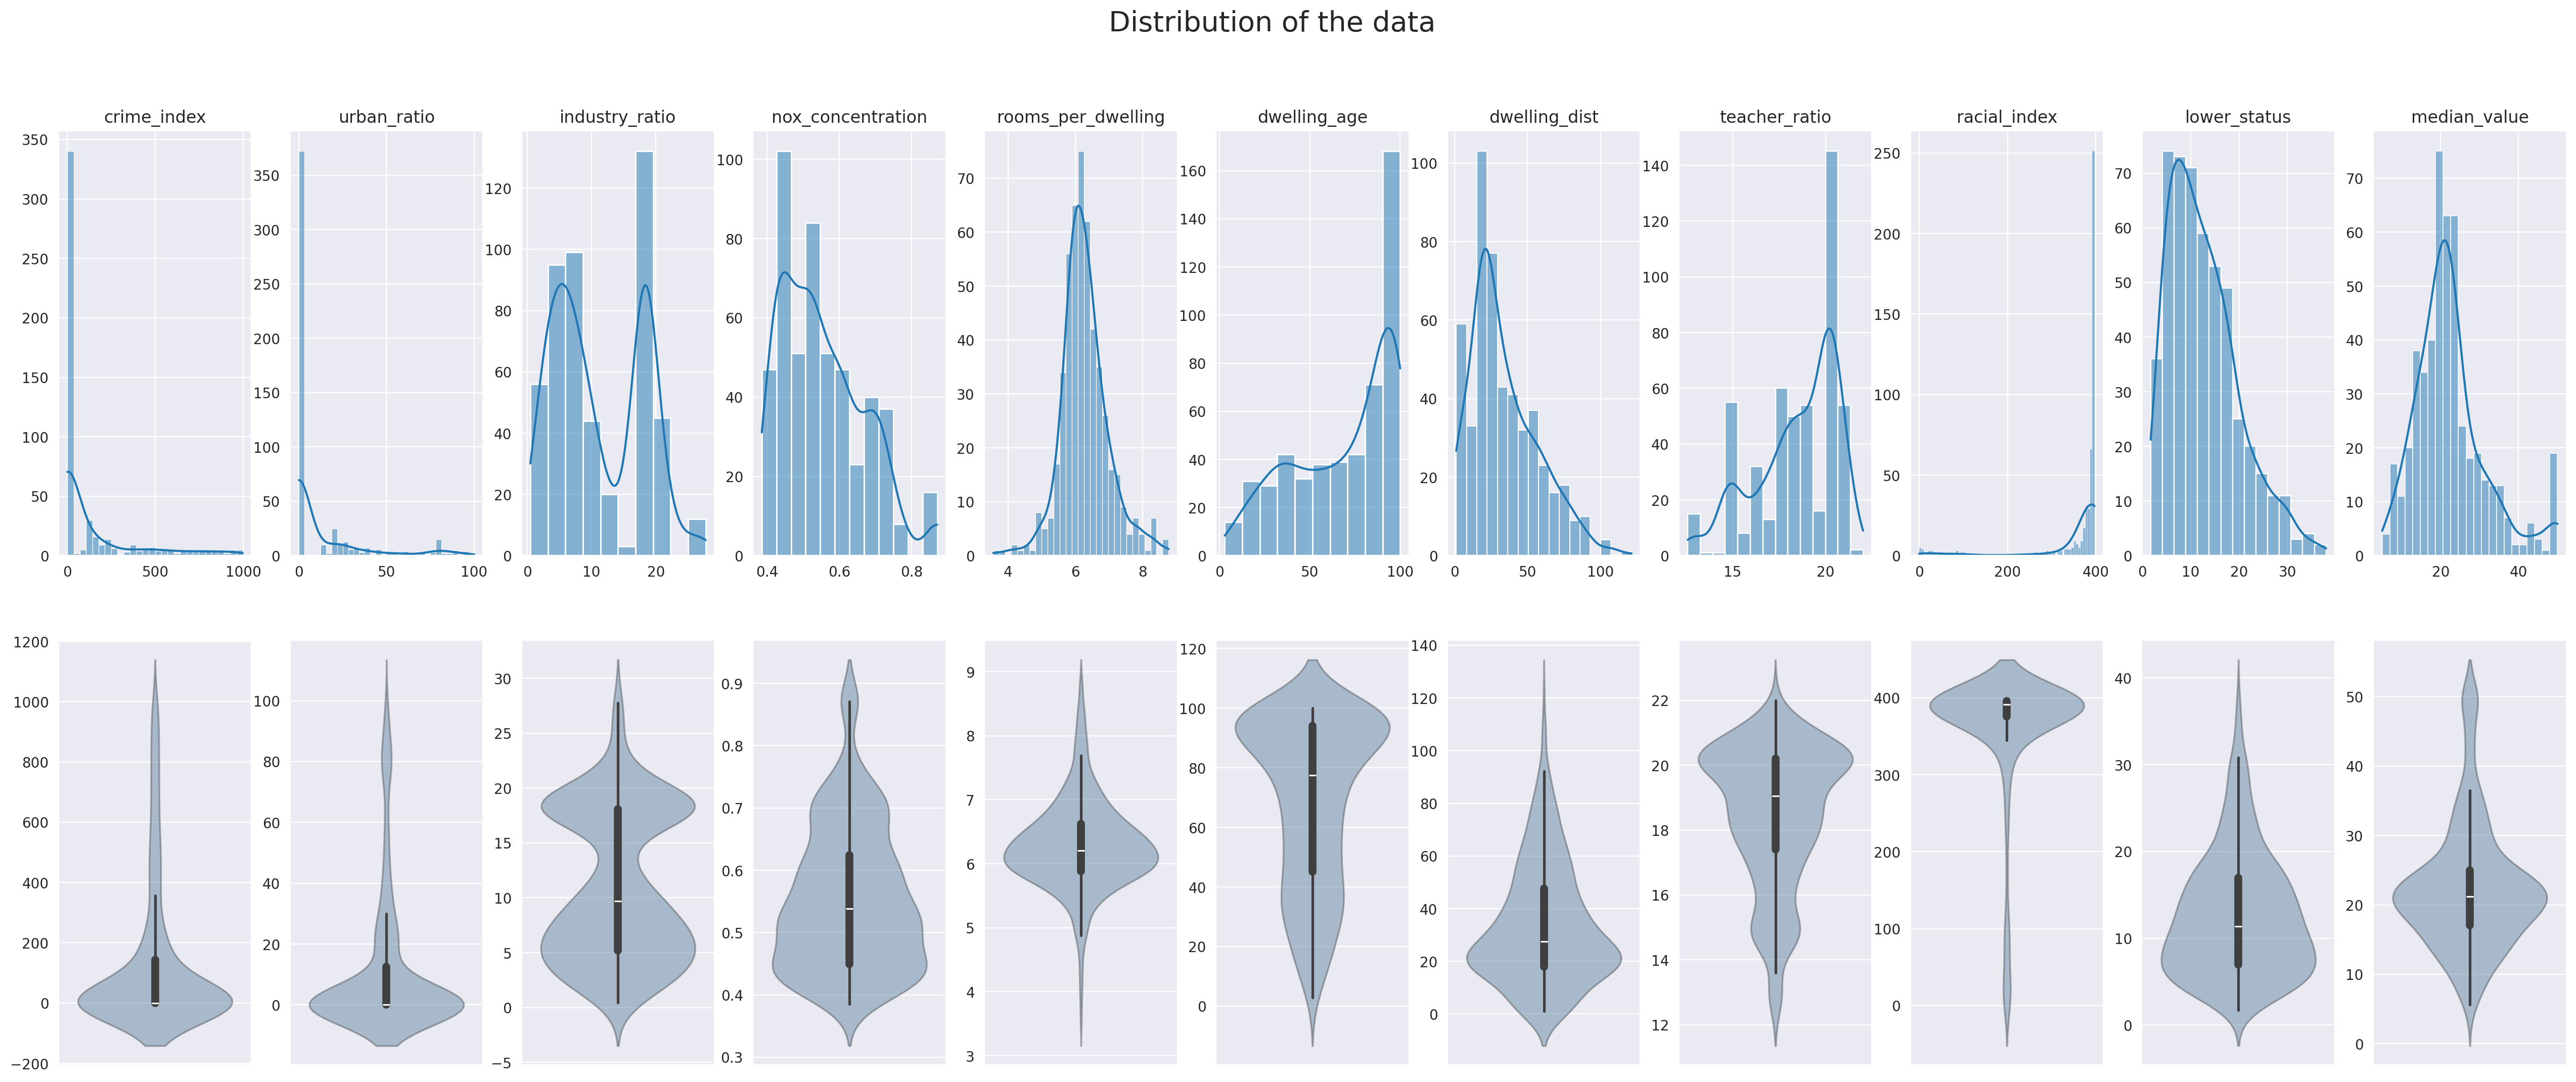

In [6]:
# First, get columns that is categoryical
# In this DataSet, all columns with int64 are categorical.(lebel encoded)
categorical_cols = data.select_dtypes(include=['int64']).columns

data_float = data.drop(columns=categorical_cols).copy()
fig, ax = plt.subplots(figsize=(32, 12), ncols = data_float.shape[1], nrows = 2, dpi=200)

for i, col in enumerate(data_float.columns):
    sns.histplot(data_float[col], ax = ax[0, i], kde = True)
    ax[0, i].set_title(col, fontsize = 12)
    ax[0, i].set_xlabel('')
    ax[0, i].set_ylabel('')
    # set fontsize in y ticks
    ax[0, i].tick_params(axis='y', labelsize=10)
    ax[0, i].tick_params(axis='x', labelsize=10)

    # boxlot in row =2 in vertical
    sns.violinplot(data_float[col], ax = ax[1, i], orient = 'v', saturation= 0.5, alpha = 0.4)
    ax[1, i].set_xlabel('')
    ax[1, i].set_ylabel('')

plt.suptitle('Distribution of the data', fontsize = 20)

plt.show()

Muy bien, esta visualizacion es muy intuitiva. Podemos ver claramente la distribucion con el KDE kernel de la densidad de la distribución en la primera fila. En la segunda fila, podemos ver violinplot como se concentran los puntos a lo largo del rango de valores, vemos como se estilan claramente las colas y la mediana.

Podemos ver como `rooms_per_dwelling` parece serguir una distribución muy cercana a la normal, la variable objetivo `median_value` tambien tiene una distribución cercana a la normal aunque con cierto ourlier en valores altos.También podemos observar como `crime_index` y `urban_ratio` parecen tener muchos valores cercanos a cero, basicamente una tasa de criminalidad muy baja, pero tambien tasa de urbanismo muy baja tambien.

El resto de variables tiene claros sesgos de cola de derecha o de izquierda. Analicemos nuestra variable objetivo `median_value` con más detalle, para entender su distribución y posibles outliers mediante un QQ plot.

Median value:  21.2


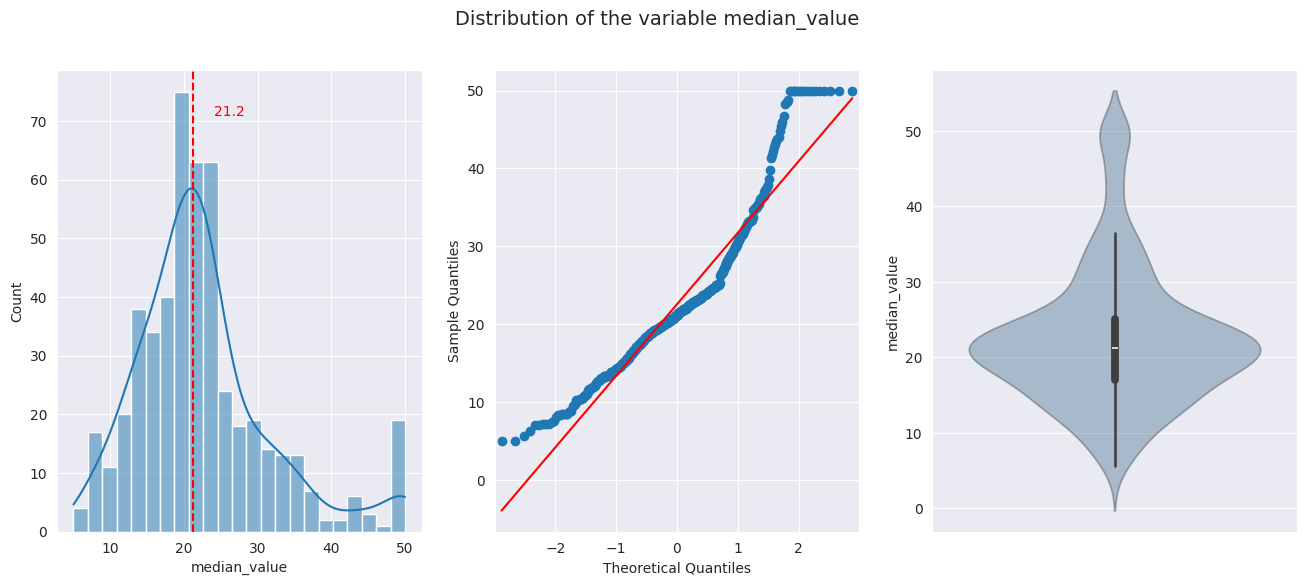

In [7]:
import statsmodels.api as sm

## QQ Plot
fig, ax = plt.subplots(figsize=(16, 6), dpi=100, ncols = 3)

sns.histplot(data['median_value'], kde = True, ax = ax[0])
ax[0].axvline(data['median_value'].median(), color='red', linestyle='--', label='Median')
# Add label text
ax[0].text(data['median_value'].median() + 5, ax[0].get_ylim()[1]*0.9, data['median_value'].median(), color='red', fontsize=10, ha='center')

sm.qqplot(data['median_value'], line = 's', ax = ax[1])
sns.violinplot(data['median_value'], orient = 'v', saturation= 0.5, alpha = 0.4, ax = ax[2])

# Print Median value
print('Median value: ', data['median_value'].median())



plt.suptitle('Distribution of the variable median_value', fontsize = 14)

plt.show()

Sin duda alguna, requiere un ajuste para normalizar la variable objetivo `media_value`, por ello no podemos determinar si se trata de viviendas de lujo o no. Esto puede ser comun en mercado inmobiliarios pero distorsionan la medicion. Tambien pueden indicar presencia de outliers, lo que puede afectar negativamente modelos posteriores.

Adicionalmente, se pueden observar truncamients en `media_value` en valores aproximados de ~50, los cuales no representan necesariamente los outliers reales, si no una limitación propia del dataset.

Sin duda, lo mas óptimo antes de realizar cualquier modelo de regresión, es realizar una transformación a la variable objetivo para terminar de ajustarla a una distribucón mas parecida a la normal. Entre las opciones puede ser una transformación logarítimica o Box-Cox.

Median value:  4.33
Lambda value:  0.22


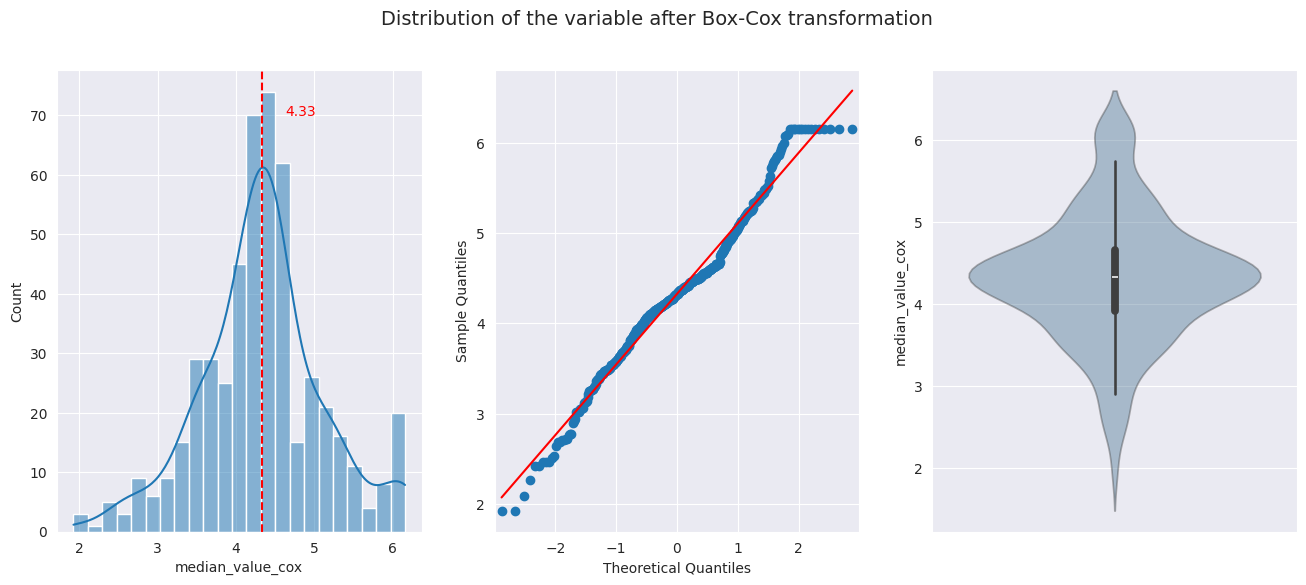

In [8]:
from scipy import stats

data['median_value_cox'], lambda_cox = stats.boxcox(data['median_value'])

fig, ax = plt.subplots(figsize=(16, 6), dpi=100, ncols = 3)

sns.histplot(data['median_value_cox'], kde = True, ax = ax[0])
ax[0].axvline(data['median_value_cox'].median(), color='red', linestyle='--', label='Median')
# Add label text
ax[0].text(data['median_value_cox'].median() + 0.5, ax[0].get_ylim()[1]*0.9, np.round(data['median_value_cox'].median(), 2), color='red', fontsize=10, ha='center')

sm.qqplot(data['median_value_cox'], line = 's', ax = ax[1])
sns.violinplot(data['median_value_cox'], orient = 'v', saturation= 0.5, alpha = 0.4, ax = ax[2])

# Print Median value
print('Median value: ', np.round(data['median_value_cox'].median(), 2))
print('Lambda value: ', np.round(lambda_cox, 2))



plt.suptitle('Distribution of the variable after Box-Cox transformation', fontsize = 14)

plt.show()

Esta transofrmación por Box-Cox soluciona la asimetría, pero no oculta del todo la presencia de Outliers. Valdría la pena realizar un análisis de outliers para determinar si es necesario eliminar algunos de ellos o no, dependiendo del modelo que se quiera utilizar posteriormente. En el momento de realizar el modelo de regresión, se harán pruebas del modelo para determinar como quedan los residuos y si eliminando algunos de estos outliers se mejora el modelo o no.

Se ha utilizado $\lambda = 0.216$ para la transformación de Box-Cox. Este es valor mas optimo que se estima bajo máxima verosimilitud. S trata de un punto intermedio entre una transformación logarítmica y una raiz.

### 1.2 Análisis de correlación

Ahora vamos a explorar como se relacionan las variables entre sí, tanto entre las variables predictoras como con la variable objetivo. Para esto, vamos a utilizar un mapa de calor de correlación y un pairplot para visualizar las relaciones entre las variables.

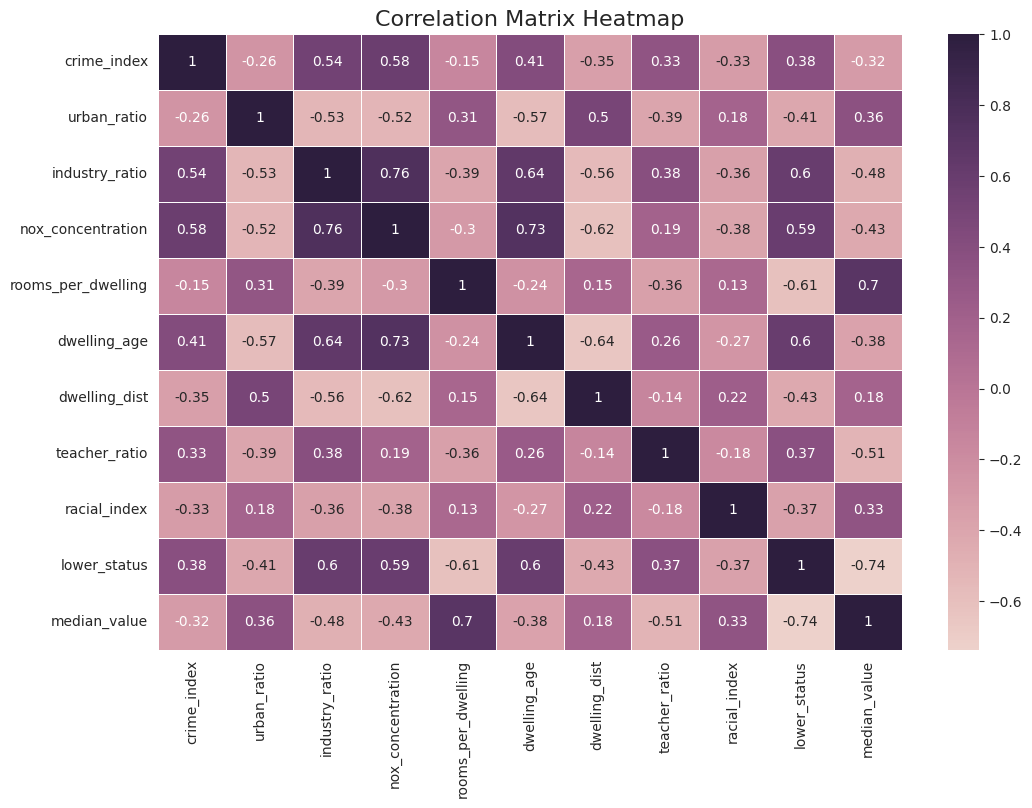

In [9]:
# Extract correlaction matrix
corr_matrix = data_float.corr()

# Plot heatmap
plt.figure(figsize=(12, 8), dpi=100)
sns.heatmap(corr_matrix, annot = True, cmap=sns.cubehelix_palette(as_cmap=True), linewidths = 0.5)
plt.title('Correlation Matrix Heatmap', fontsize = 16)
plt.show()

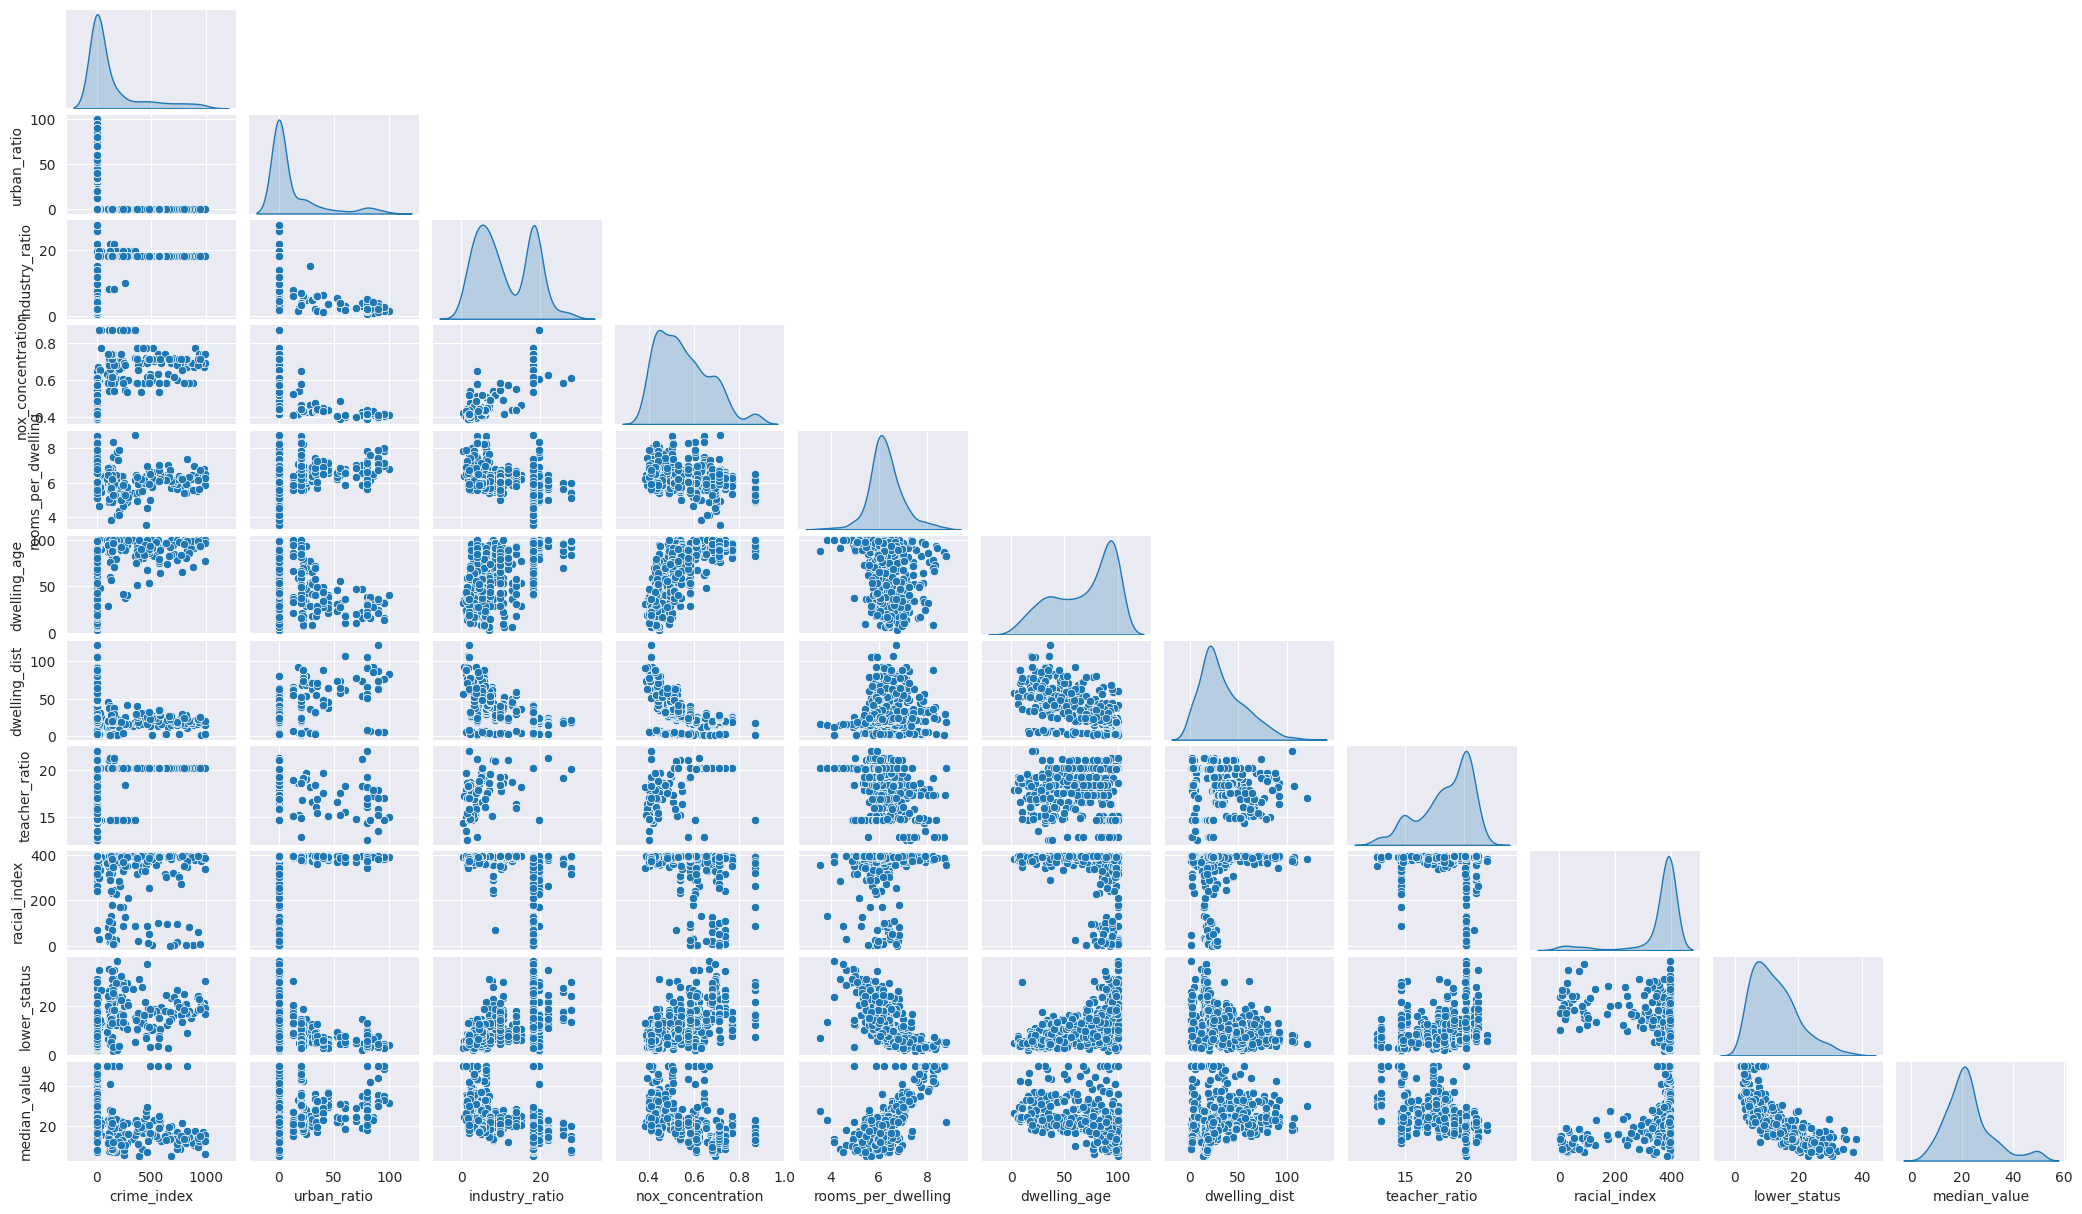

In [10]:
ax = sns.pairplot(data_float, diag_kind='kde', corner=True)
# labels size to 10
ax.fig.set_size_inches(21, 12)
for ax in ax.axes.flatten():
    if ax is not None:
        ax.tick_params(labelsize=10)

plt.show()


El heatmap nos ayuda a entender fuerza y direccion de correlación entre las variables, mientras el pairplot nos ayuda a entender la distribucion de cada variable y la relacion entre cada par de variables, lo que nos puede ayudar a identificar relaciones no lineales entre las variables.

`crime_index` parece coincidir con `urban_ratio` parecen indicar presencia de inmuebles en zona rural son los que registran una tasa de criminalidad muy baja. El fenómeno es curioso y necesitamos explorar ambas variables para entender mejor esta relación.

Existen correlaciones positivas entre `median_value` y `rooms_per_dwelling`, ha mayor numero de habitaciones por vivienda, mayor precio. De igual manera una correlación negativa, ha mayor porcentaje de población de clase baja `lower_status`, menor precio promedio y a su vez, menor cantidad de habitaciones por vivienda. Zonas populares se prioriza la cantidad de viviendas por sobre la calidad de las mismas, lo que se traduce en un menor precio promedio de las viviendas.

Con `dwelling_dist` existe una correlación negativa con respecto al `nox_concentration`, lo que indica a que a mayor distancia a los centros urbanos, menor concentración de óxido nitroso.

El resto de variables, parecen comportarse de forma mas dispera con respecto a otras, sin patrones claros de correlación, lo que puede indicar que no existe una relación lineal entre estas variables.

Print Dendograms and Clusters of Correlation Matrix

<Figure size 1200x800 with 0 Axes>

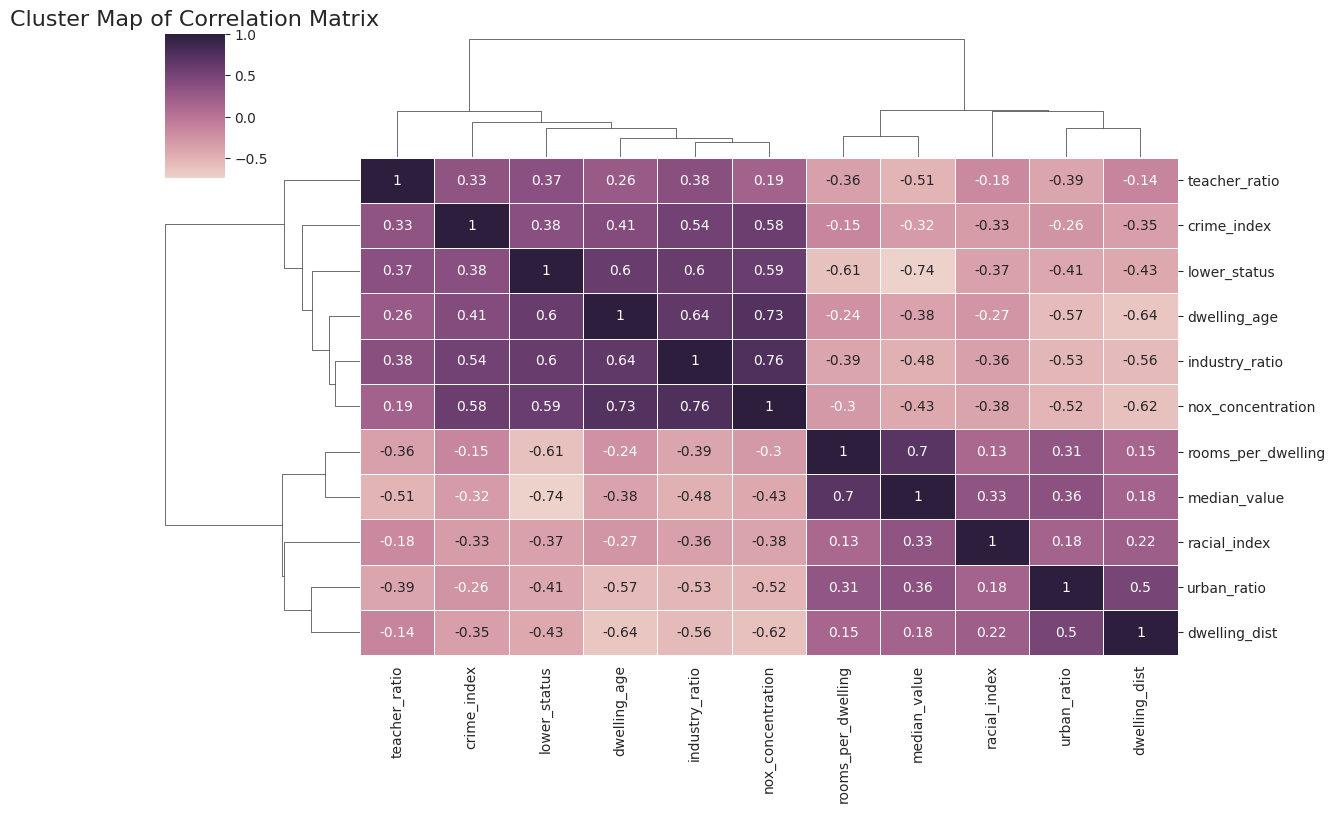

In [11]:
plt.figure(figsize=(12, 8), dpi=100)
sns.clustermap(
    corr_matrix, annot = True, cmap=sns.cubehelix_palette(as_cmap=True), linewidths = 0.5, figsize=(12, 8)
)
plt.title('Cluster Map of Correlation Matrix', fontsize = 16)

plt.show()

Aquí se confirma esa fuerza de correlaciones cuando lo organizamos a través de un cluster map o dendogramas. Encontramos como se agrupan las variables segun su fuerza de correlación y las primeras en agruparse son `urban_ratio` y `dwelling_dist`. `rooms_per_dwelling` con `median_value` como habíamos observado antes, pero tmabien el `industry_ratio` con `nox_concentration` donde su segunda fuerza de relación llega `dewelling_age`, esto puede sugerir cierto nivel de **multicolinealidad** entre las variables y afectar negativamente a la estabilidad de modelos lineales.

## PCA

Le dataset incluye por tanto 13 variables predictoras, lo que puede suponer un problema de dimensionalidad. Además, parece existir cierta multicolinalidad entre algunas variables, por lo que se antoja necesario realizar un proceso de reduccion de dimensionalidad con la finalidad de reducir el ruido de fondo y entender mejor la estructura subyacente de los datos. Para esto, vamos a utlizar el método de análisis de componentes principales (PCA), lo que nos permite reducir la dimensionalidad del dataset y a su vez entender cual es el aporte de varianza de cada una de las componentes principale y cuales son las variables que mas aportan a cada una de estas.

Se realiza a su vez una estandarización de los datos antes de aplicar el PCA, esto es necesario para que el PCA no se vea afectado por la escala de las variables. Se descartará el uso de variables categóricas binarias como `c_river_variable` para el PCA, ya que estas al arrojar valores de 0 y 1, la varianza de esta vaiable es muy baja y no aporta información relevante para la reducción de la dimensionalidad, el PCA espera vairables continuas, estas variables binarias terminarán siendo ignoradas.

Una vez estandarizados, aplicamos el PCA e iniciamos con la visualización de la varianza explicada acumulada para determinar el número óptimo de componentes principales a retener.

In [30]:
# import libraries
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_float)

data_scaled = pd.DataFrame(data_scaled, columns=data_float.columns)

# Drop target variable
data_scaled = data_scaled.drop(columns=['median_value'])

# PCA instance and fit
pca = PCA()
pca.fit(data_scaled)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
# Cumulative explained variance
cumulative_explained_var = np.cumsum(explained_var)

Procedemos a visualizar la varianza explicada acumulada para determinar el número óptimo de componentes principales.

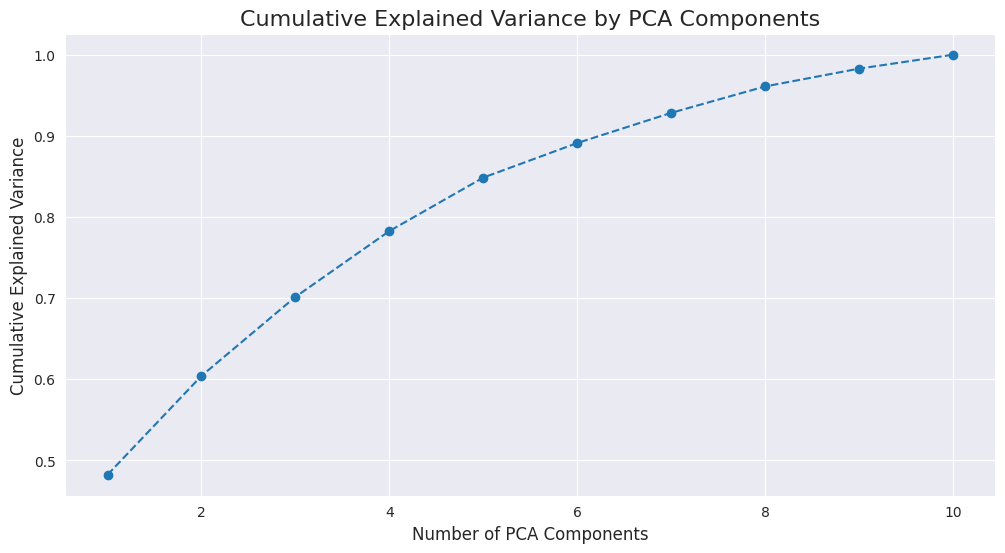

In [31]:
n_components = range(1, len(explained_var) + 1 )

plt.figure(figsize=(12, 6), dpi=100)
plt.plot(n_components, cumulative_explained_var, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components', fontsize = 16)
plt.xlabel('Number of PCA Components', fontsize = 12)
plt.ylabel('Cumulative Explained Variance', fontsize = 12)

plt.show()

In [29]:
pca.explained_variance_ratio_

array([0.48246233, 0.12182751, 0.09729671, 0.08113323, 0.06586314,
       0.04261522, 0.03715736, 0.03257954, 0.02192215, 0.01714282])